# Load Parquet Dataset with Pandas

This notebook loads `nyc_taxi_ml_dataset_2024_2025.parquet` using pandas and prints a quick preview and basic schema info.


In [1]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("nyc_taxi_ml_dataset_2024_2025.parquet")
df = pd.read_parquet(DATA_PATH)

df.head()

,pickup_datetime,provider,dropoff_datetime,PULocationID,DOLocationID,trip_distance,trip_time,fare_amount,tax,tolls_amount,...,cost_per_mile,temperature,precipitation,weathercode,windspeed,weather_clear,weather_cloudy,weather_rain,weather_snow,dataset_split
0,2024-01-23 00:50:15,1,2024-01-23 01:21:53,132,33,26.62,1898,96.8,0.5,0.0,...,4.542074,30.2,0.0,3.0,11.6,0,1,0,0.0,train
1,2024-01-14 20:21:20,1,2024-01-14 20:26:25,236,43,0.76,305,7.2,0.5,0.0,...,18.026316,27.6,0.0,1.0,12.1,0,1,0,0.0,train
2,2024-01-23 00:23:16,1,2024-01-23 00:25:55,246,50,0.70,159,5.8,0.5,0.0,...,20.057143,30.2,0.0,3.0,11.6,0,1,0,0.0,train
3,2024-01-13 20:31:32,1,2024-01-13 20:40:59,113,90,1.00,567,10.0,0.5,0.0,...,17.250000,39.5,0.0,1.0,16.7,0,1,0,0.0,train
4,2024-01-10 09:23:39,1,2024-01-10 09:29:49,170,234,0.70,370,7.2,0.5,0.0,...,19.142857,47.5,0.0,3.0,16.7,0,1,0,0.0,train


In [2]:
print("shape:", df.shape)
df.info()

shape: (38202226, 26)
<class 'pandas.DataFrame'>
RangeIndex: 38202226 entries, 0 to 38202225
Data columns (total 26 columns):
 #   Column                Dtype         
---  ------                -----         
 0   pickup_datetime       datetime64[us]
 1   provider              int64         
 2   dropoff_datetime      datetime64[us]
 3   PULocationID          int32         
 4   DOLocationID          int32         
 5   trip_distance         float64       
 6   trip_time             int64         
 7   fare_amount           float64       
 8   tax                   float64       
 9   tolls_amount          float64       
 10  total_amount          float64       
 11  congestion_surcharge  float64       
 12  airport_fee           float64       
 13  cbd_congestion_fee    float64       
 14  speed_mph             float64       
 15  in_cbd_zone           int64         
 16  cost_per_mile         float64       
 17  temperature           float64       
 18  precipitation         float64

In [4]:
# Missingness by column (top 25)
missing_rate = df.isna().mean().sort_values(ascending=False)
missing_rate.head(25)

weather_snow            6.358140e-01
congestion_surcharge    8.758757e-03
airport_fee             8.758757e-03
windspeed               1.570589e-07
weathercode             1.570589e-07
precipitation           1.570589e-07
temperature             1.570589e-07
pickup_datetime         0.000000e+00
speed_mph               0.000000e+00
weather_rain            0.000000e+00
weather_cloudy          0.000000e+00
weather_clear           0.000000e+00
cost_per_mile           0.000000e+00
in_cbd_zone             0.000000e+00
cbd_congestion_fee      0.000000e+00
provider                0.000000e+00
total_amount            0.000000e+00
tolls_amount            0.000000e+00
tax                     0.000000e+00
fare_amount             0.000000e+00
trip_time               0.000000e+00
trip_distance           0.000000e+00
DOLocationID            0.000000e+00
PULocationID            0.000000e+00
dropoff_datetime        0.000000e+00
dtype: float64

## Directions → analysis plan (what we will answer)

From `directions.md`, the core questions are:

- **Demand impact**: How does congestion pricing affect trip volume in/out of the CBD congestion zone?
- **Price sensitivity**: What is the elasticity of demand to fare changes (including the CBD congestion fee)?
- **Behavioral changes**: Do travelers shift *when* they travel, *where* they travel, or *which provider* they use?
- **Revenue optimization**: What fee/pricing levels can maintain revenue while managing demand?

### Important modeling note (from professor)

We will **avoid a pure time-series forecast** and instead build an **event-based / matrix-style dataset**:
- Each row is a trip (or an aggregated “bucket” of trips) with labeled features.
- We use **2024 as pre-policy** and **2025 as post-policy** for before/after comparisons.

### Practical constraint

The dataset is very large (~38M rows, ~6.5GB in memory). For modeling and iterative EDA we will:
- Compute a few simple headline aggregates on the **full** dataframe.
- Create a **random sample** for plots and machine learning models to keep the notebook runnable.

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

RANDOM_STATE = 42

# --- Create a modeling/EDA sample ---
# Adjust SAMPLE_N down if you hit memory pressure.
SAMPLE_N = 1_000_000

if len(df) > SAMPLE_N:
    df_sample = df.sample(n=SAMPLE_N, random_state=RANDOM_STATE).copy()
else:
    df_sample = df.copy()

# Event-based labeled features (matrix style)
for _d in [df_sample]:
    _d["year"] = _d["pickup_datetime"].dt.year
    _d["month"] = _d["pickup_datetime"].dt.month
    _d["dow"] = _d["pickup_datetime"].dt.dayofweek  # 0=Mon
    _d["hour"] = _d["pickup_datetime"].dt.hour
    _d["post_policy"] = (_d["year"] >= 2025).astype(int)

df_sample.head()

,pickup_datetime,provider,dropoff_datetime,PULocationID,DOLocationID,trip_distance,trip_time,fare_amount,tax,tolls_amount,total_amount,congestion_surcharge,airport_fee,cbd_congestion_fee,speed_mph,in_cbd_zone,cost_per_mile,temperature,precipitation,weathercode,windspeed,weather_clear,weather_cloudy,weather_rain,weather_snow,dataset_split,year,month,dow,hour,post_policy
27266793,2025-05-11 19:53:14,2,2025-05-11 20:09:06,26,11,3.89,952,21.48,1.91,0.00,23.93,0.00,0.0,0.00,14.710084,0,6.151671,17.9,0.000,3.0,5.8,0,1,0,NaN,train,2025,5,6,19,1
37590168,2025-11-22 00:05:04,2,2025-11-22 00:43:28,107,89,10.58,2304,50.88,4.52,0.00,59.39,2.75,0.0,2.50,16.531250,1,5.613422,7.1,0.000,3.0,3.6,0,1,0,0.0,test,2025,11,5,0,1
5049177,2024-03-19 21:27:37,2,2024-03-19 22:07:02,246,21,11.74,2365,60.22,5.96,6.94,89.37,2.75,0.0,0.00,17.870613,1,7.612436,36.9,0.012,71.0,2.7,0,0,0,1.0,train,2024,3,1,21,0
36623690,2025-11-19 11:47:33,1,2025-11-19 12:11:46,148,145,4.76,1453,25.13,0.50,0.00,29.88,0.00,0.0,1.25,11.793531,1,6.277311,5.4,0.000,3.0,7.8,0,1,0,0.0,test,2025,11,2,11,1
3611123,2024-03-22 02:28:04,1,2024-03-22 02:41:22,79,87,4.04,798,20.50,0.50,0.00,30.60,2.50,0.0,0.00,18.225564,1,7.574257,26.3,0.000,0.0,6.7,1,0,0,0.0,train,2024,3,4,2,0


## 1) Demand impact (trip volume in/out of the CBD zone)

We start with a **before/after** comparison:

- **Pre-policy**: 2024
- **Post-policy**: 2025

We’ll measure:

- **Total trips** by year
- **CBD-exposed trips** (`in_cbd_zone = 1`) vs **non-CBD trips** (`in_cbd_zone = 0`)
- **Share of trips in the CBD zone** and how it changes post-policy

This directly addresses: *“How does congestion pricing affect trip volume in/out of congestion zones?”*

In [5]:
# Full-data headline counts by year x CBD exposure
# (kept lightweight: only computes year from the datetime Series)
year_full = df["pickup_datetime"].dt.year
counts_year_cbd = pd.crosstab(year_full, df["in_cbd_zone"], margins=True)
counts_year_cbd.columns = ["non_cbd" if c == 0 else "in_cbd" if c == 1 else c for c in counts_year_cbd.columns]

counts_year_cbd

,non_cbd,in_cbd,All
pickup_datetime,,,
2002,1,0,1
2009,0,1,1
2023,1,1,2
2024,10100820,9020986,19121806
2025,10396082,8684334,19080416
All,20496904,17705322,38202226


In [6]:
# Compute CBD share by year
counts = counts_year_cbd.drop(index="All", errors="ignore").copy()
counts["total"] = counts.sum(axis=1)
counts["cbd_share"] = counts["in_cbd"] / counts["total"]
counts[["in_cbd", "non_cbd", "total", "cbd_share"]].sort_index()

,in_cbd,non_cbd,total,cbd_share
pickup_datetime,,,,
2002,0,1,2,0.000000
2009,1,0,2,0.500000
2023,1,1,4,0.250000
2024,9020986,10100820,38243612,0.235882
2025,8684334,10396082,38160832,0.227572


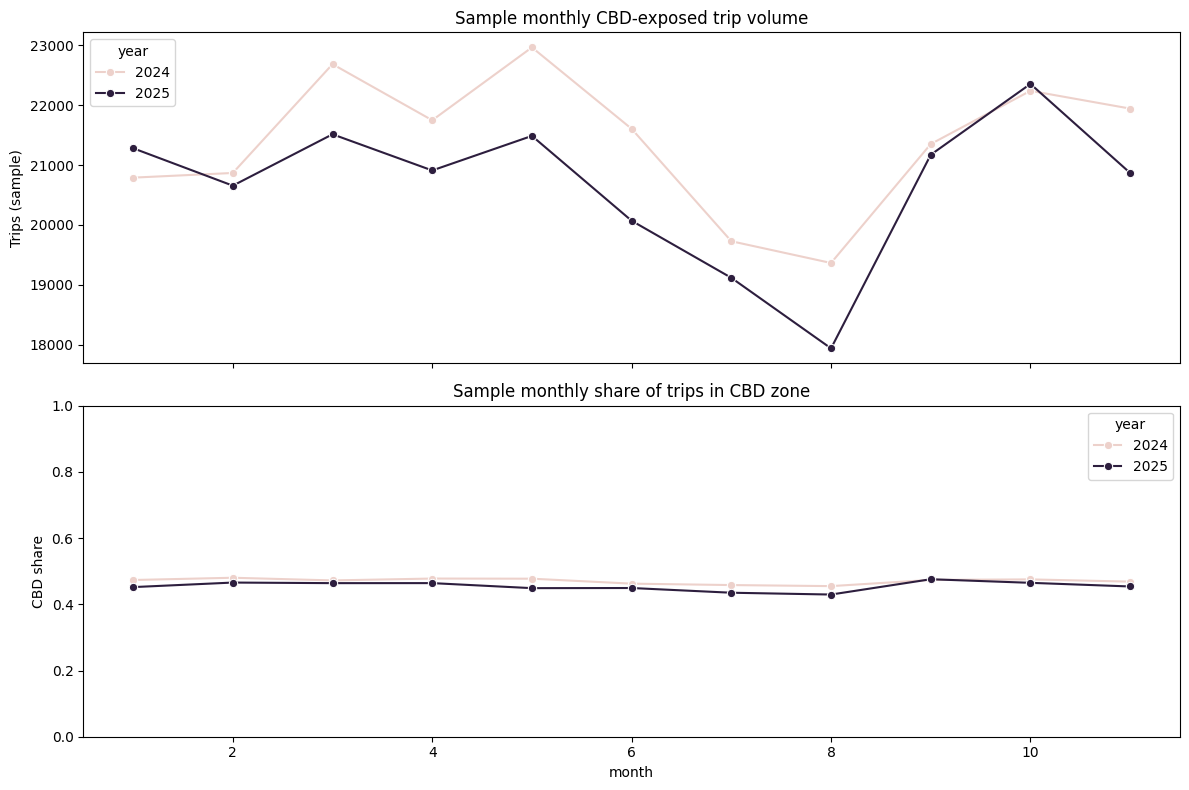

,year,month,non_cbd,in_cbd,total,cbd_share
0,2024,1,23135,20790,43925,0.473307
1,2024,2,22594,20868,43462,0.480144
2,2024,3,25369,22685,48054,0.472073
3,2024,4,23777,21748,45525,0.477716
4,2024,5,25153,22965,48118,0.477264


In [7]:
# More detailed view (sample): monthly trend of CBD share and volumes
monthly = (
    df_sample
    .groupby(["year", "month", "in_cbd_zone"], as_index=False)
    .size()
    .rename(columns={"size": "trip_count"})
)

monthly_pivot = monthly.pivot_table(
    index=["year", "month"],
    columns="in_cbd_zone",
    values="trip_count",
    fill_value=0,
    aggfunc="sum",
)
monthly_pivot.columns = ["non_cbd" if c == 0 else "in_cbd" for c in monthly_pivot.columns]
monthly_pivot = monthly_pivot.reset_index()
monthly_pivot["total"] = monthly_pivot["in_cbd"] + monthly_pivot["non_cbd"]
monthly_pivot["cbd_share"] = monthly_pivot["in_cbd"] / monthly_pivot["total"].replace(0, np.nan)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sns.lineplot(data=monthly_pivot, x="month", y="in_cbd", hue="year", marker="o", ax=axes[0])
axes[0].set_title("Sample monthly CBD-exposed trip volume")
axes[0].set_ylabel("Trips (sample)")

sns.lineplot(data=monthly_pivot, x="month", y="cbd_share", hue="year", marker="o", ax=axes[1])
axes[1].set_title("Sample monthly share of trips in CBD zone")
axes[1].set_ylabel("CBD share")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

monthly_pivot.head()

## 2) Behavioral segmentation (identify travel segments)

To connect pricing policy to behavior, we first identify **trip/behavioral segments** using unsupervised learning.

- We’ll build a matrix of trip features (distance, time, speed, cost per mile, weather, time-of-day, CBD exposure, etc.).
- Then we’ll run **K-Means** on a manageable subsample.
- Finally, we’ll profile clusters to interpret them as behavioral segments (e.g., short CBD trips vs long airport-like trips, etc.).

This supports the directions’ goal of **segmenting travelers** before estimating sensitivity and behavioral shifts.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Keep clustering small (KMeans is O(n*k*i))
CLUSTER_N = 200_000
cluster_df = df_sample.sample(n=min(CLUSTER_N, len(df_sample)), random_state=RANDOM_STATE).copy()

cluster_features_num = [
    "trip_distance",
    "trip_time",
    "speed_mph",
    "cost_per_mile",
    "total_amount",
    "congestion_surcharge",
    "airport_fee",
    "cbd_congestion_fee",
    "temperature",
    "precipitation",
    "windspeed",
    "hour",
    "dow",
]
cluster_features_cat = [
    "provider",
    "in_cbd_zone",
]

cluster_df = cluster_df.replace([np.inf, -np.inf], np.nan)
cluster_df = cluster_df.dropna(subset=cluster_features_num + cluster_features_cat)

preprocess_cluster = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), cluster_features_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cluster_features_cat),
    ],
    remainder="drop",
)

K = 6  # adjustable; we can revisit based on interpretability
cluster_model = Pipeline(
    steps=[
        ("prep", preprocess_cluster),
        ("kmeans", KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)),
    ]
)

cluster_df["segment"] = cluster_model.fit_predict(cluster_df)

segment_profile = (
    cluster_df
    .groupby("segment")
    .agg(
        n_trips=("segment", "size"),
        avg_distance=("trip_distance", "mean"),
        avg_time_s=("trip_time", "mean"),
        avg_speed=("speed_mph", "mean"),
        avg_total_amount=("total_amount", "mean"),
        cbd_share=("in_cbd_zone", "mean"),
        post_share=("post_policy", "mean"),
    )
    .sort_values("n_trips", ascending=False)
)

segment_profile

In [ ]:
# Visualize segments (distance vs total amount)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=cluster_df.sample(n=min(50_000, len(cluster_df)), random_state=RANDOM_STATE),
    x="trip_distance",
    y="total_amount",
    hue="segment",
    alpha=0.25,
    linewidth=0,
)
plt.title("Behavioral segments (sample): distance vs total amount")
plt.xlabel("Trip distance")
plt.ylabel("Total amount")
plt.legend(title="segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 3) Price sensitivity (elasticity of demand)

We want an empirical estimate of **how sensitive demand is to price**.

Because we do not observe *individual riders’ choice sets*, we approximate demand at an aggregate level:

- Create “buckets” of trips (e.g., by year/month/hour/provider/CBD exposure).
- For each bucket, compute:
  - `trip_count` (demand proxy)
  - `avg_price` (average `total_amount`)
  - controls (weather, time-of-day mix)

Then we estimate a count model:

\[
\log(\mathbb{E}[\text{trip_count}]) = \beta_0 + \beta_1 \log(\text{avg_price}) + \dots
\]

In this log-link / log-price setup, **\(\beta_1\)** is interpretable as a (semi-)elasticity of trip counts w.r.t. price.

We fit on **2024 (pre-policy)** to estimate baseline price sensitivity, then later use it for what-if fee simulations.

In [ ]:
from sklearn.linear_model import PoissonRegressor
from sklearn.model_selection import train_test_split

# Aggregate to buckets (sample-based for runtime)
agg_keys = ["year", "month", "dow", "hour", "provider", "in_cbd_zone"]

agg = (
    df_sample
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["total_amount", "temperature", "precipitation", "windspeed"])  # minimal needed
    .groupby(agg_keys, as_index=False)
    .agg(
        trip_count=("total_amount", "size"),
        avg_price=("total_amount", "mean"),
        avg_distance=("trip_distance", "mean"),
        avg_trip_time=("trip_time", "mean"),
        avg_temp=("temperature", "mean"),
        avg_precip=("precipitation", "mean"),
        avg_wind=("windspeed", "mean"),
        avg_cbd_fee=("cbd_congestion_fee", "mean"),
    )
)

agg["log_price"] = np.log(agg["avg_price"].clip(lower=1e-3))

# Use 2024 only to estimate baseline elasticity
agg_2024 = agg[agg["year"] == 2024].copy()

feature_cols_num = [
    "log_price",
    "avg_distance",
    "avg_trip_time",
    "avg_temp",
    "avg_precip",
    "avg_wind",
]
feature_cols_cat = ["month", "dow", "hour", "provider", "in_cbd_zone"]

X = agg_2024[feature_cols_num + feature_cols_cat]
y = agg_2024["trip_count"]

preprocess_elastic = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(with_mean=False), feature_cols_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat),
    ]
)

elastic_model = Pipeline(
    steps=[
        ("prep", preprocess_elastic),
        ("pois", PoissonRegressor(alpha=1e-6, max_iter=1000)),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
elastic_model.fit(X_train, y_train)

# Pull the coefficient on log_price (first numeric column after preprocessing)
# Note: because we scaled numeric features, the raw coefficient is on the scaled log_price.
# We'll compute elasticity by refitting without scaling for a clean interpretation.
elastic_model

In [ ]:
# Refit without scaling numeric features so the log_price coefficient is directly interpretable
preprocess_elastic_noscale = ColumnTransformer(
    transformers=[
        ("num", "passthrough", feature_cols_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat),
    ]
)

elastic_model_noscale = Pipeline(
    steps=[
        ("prep", preprocess_elastic_noscale),
        ("pois", PoissonRegressor(alpha=1e-6, max_iter=1000)),
    ]
)

elastic_model_noscale.fit(X_train, y_train)

# Extract feature names and coefficients
prep = elastic_model_noscale.named_steps["prep"]
pois = elastic_model_noscale.named_steps["pois"]

feature_names = prep.get_feature_names_out()
coef = pd.Series(pois.coef_, index=feature_names).sort_values()

elasticity_est = coef.get("num__log_price", np.nan)

print("Estimated demand elasticity (pre-policy, 2024 buckets):", elasticity_est)
coef.tail(15)

## 4) Behavioral changes (timing, provider selection, and location)

Here we look for shifts that suggest avoidance or adaptation:

- **Timing**: do CBD trips move to different hours/days?
- **Provider selection**: does the share of `provider` change post-policy (especially for CBD-exposed trips)?
- **Location choice**: do the most common pickup/dropoff zones shift after the policy?

These analyses are descriptive but provide concrete evidence of behavioral change patterns.

In [ ]:
# Focus on CBD-exposed trips to see within-zone behavioral shifts
cbd = df_sample[df_sample["in_cbd_zone"] == 1].copy()

# Timing: hour-of-day distribution pre vs post
hour_dist = (
    cbd
    .groupby(["post_policy", "hour"], as_index=False)
    .size()
    .rename(columns={"size": "n"})
)
hour_dist["share"] = hour_dist.groupby("post_policy")["n"].transform(lambda s: s / s.sum())

plt.figure(figsize=(12, 5))
sns.lineplot(data=hour_dist, x="hour", y="share", hue="post_policy", marker="o")
plt.title("CBD trips: hour-of-day share (0=pre/2024, 1=post/2025) [sample]")
plt.ylabel("Share of CBD trips")
plt.show()

# Provider share pre vs post (CBD only)
prov_share = (
    cbd
    .groupby(["post_policy", "provider"], as_index=False)
    .size()
    .rename(columns={"size": "n"})
)
prov_share["share"] = prov_share.groupby("post_policy")["n"].transform(lambda s: s / s.sum())

plt.figure(figsize=(10, 4))
sns.barplot(data=prov_share, x="provider", y="share", hue="post_policy")
plt.title("CBD trips: provider share pre vs post [sample]")
plt.ylabel("Share")
plt.show()

prov_share

In [ ]:
# Location shifts: top pickup/dropoff zones pre vs post (CBD trips)
# Note: without a TLC zone lookup table, we interpret changes by LocationID.

def top_locations(d, col, k=15):
    tmp = (
        d.groupby(["post_policy", col], as_index=False)
        .size()
        .rename(columns={"size": "n"})
    )
    # Keep top-k per period
    tmp["rank"] = tmp.groupby("post_policy")["n"].rank(method="first", ascending=False)
    tmp = tmp[tmp["rank"] <= k].sort_values(["post_policy", "n"], ascending=[True, False])
    return tmp

pu_top = top_locations(cbd, "PULocationID", k=15)
do_top = top_locations(cbd, "DOLocationID", k=15)

display(pu_top)
display(do_top)

# Simple overlap metric (how many top pickup zones are common between periods)
pu_2024 = set(pu_top[pu_top["post_policy"] == 0]["PULocationID"])
pu_2025 = set(pu_top[pu_top["post_policy"] == 1]["PULocationID"])
print("Top PU overlap (CBD trips):", len(pu_2024 & pu_2025), "/", len(pu_2024 | pu_2025))

## 5) Revenue optimization (what-if analysis on CBD congestion fee)

Using the elasticity estimate from section 3, we can simulate how changing the CBD fee might affect:

- **Demand** (trip counts in CBD-exposed buckets)
- **Revenue per trip** (higher fee increases price)
- **Total revenue** (price × demand)

We do a simple what-if on the **CBD-exposed market**:

- Let \(e\) be the estimated elasticity.
- If baseline price is \(P_0\) and we set a new price \(P\), demand scales as:

\[
Q(P) = Q_0 \left(\frac{P}{P_0}\right)^e
\]

This is not a full equilibrium model, but it gives a transparent, data-driven starting point for fee strategy discussions.

In [ ]:
# What-if simulation: vary CBD fee and compute implied revenue changes (sample-based)

# Baseline: use 2025 CBD trips in the sample
cbd_2025 = df_sample[(df_sample["in_cbd_zone"] == 1) & (df_sample["year"] == 2025)].copy()

# If sample has limited 2025 rows, fall back to all CBD sample
if len(cbd_2025) < 10_000:
    cbd_2025 = df_sample[df_sample["in_cbd_zone"] == 1].copy()

P0 = cbd_2025["total_amount"].clip(lower=1e-3).mean()
Q0 = len(cbd_2025)
fee0 = cbd_2025["cbd_congestion_fee"].fillna(0).mean()

# Elasticity from section 3
try:
    e = float(elasticity_est)
except Exception:
    e = np.nan

print("Baseline (sample) P0:", P0)
print("Baseline (sample) Q0:", Q0)
print("Baseline (sample) avg CBD fee:", fee0)
print("Elasticity e:", e)

# Fee grid (in dollars). Adjust range as needed.
fee_grid = np.arange(0, 25.5, 0.5)

# Approximate price change by adding (new_fee - old_fee)
P = (P0 + (fee_grid - fee0)).clip(min=1e-3)

# Demand response curve
Q = Q0 * (P / P0) ** e if np.isfinite(e) else np.full_like(P, np.nan, dtype=float)

# Revenue curve
R = P * Q

sim = pd.DataFrame({"fee": fee_grid, "price": P, "demand": Q, "revenue": R})

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(sim["fee"], sim["demand"]) 
plt.title("Implied demand vs CBD fee")
plt.xlabel("CBD fee")
plt.ylabel("Implied demand (index to sample baseline)")

plt.subplot(1, 2, 2)
plt.plot(sim["fee"], sim["revenue"]) 
plt.title("Implied revenue vs CBD fee")
plt.xlabel("CBD fee")
plt.ylabel("Implied revenue")
plt.tight_layout()
plt.show()

sim.sort_values("revenue", ascending=False).head(10)